In [2]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [3]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [4]:
ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")
ds_truth = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

In [5]:
ds_forecast

<xarray.Dataset> Size: 5GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 42, latitude: 33)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * longitude                 (longitude) float64 336B 88.5 90.0 ... 148.5 150.0
  * latitude                  (latitude) float64 264B -16.5 -15.0 ... 30.0 31.5
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 1GB ...

In [6]:
# import tensorflow and required stuff from Keras API
import tensorflow as tf

# all the layers used for U-net
from tensorflow.keras.layers import (Activation, BatchNormalization, Concatenate, Conv2D,
                                     Conv2DTranspose, Input, MaxPool2D
)
from tensorflow.keras.models import Model

def conv_block(inputs, num_filters: int, kernel: tuple = (3,3), padding: str = "same",
               activation: str = "relu", kernel_init: str = "he_normal", l_batch_normalization: bool = True):
    """
    A convolutional layer with optional batch normalization
    :param inputs: the input data with dimensions nx, ny and nc
    :param num_filters: number of filters (output channel dimension)
    :param kernel: tuple indictating kernel size
    :param padding: technique for padding (e.g. "same" or "valid")
    :param activation: activation fuction for neurons (e.g. "relu")
    :param kernel_init: initialization technique (e.g. "he_normal" or "glorot_uniform")
    """
    
    x = Conv2D(num_filters, kernel, padding=padding, kernel_initializer=kernel_init)(inputs)
    if l_batch_normalization:
        x = BatchNormalization()(x)
    x = Activation(activation)(x)
    
    return x

def conv_block_n(inputs, num_filters, n=2, kernel=(3,3), padding="same", activation="relu", 
                     kernel_init="he_normal", l_batch_normalization=True):
    """
    Sequential application of two convolutional layers (using conv_block).
    """
    
    x = conv_block(inputs, num_filters, kernel, padding, activation,
                   kernel_init, l_batch_normalization)
    for i in np.arange(n-1):
        x = conv_block(x, num_filters, kernel, padding, activation,
                       kernel_init, l_batch_normalization)
    
    return x

def encoder_block(inputs, num_filters, kernel_maxpool: tuple=(2,2), l_large: bool=True):
    """
    One complete encoder-block used in U-net
    """
    if l_large:
        x = conv_block_n(inputs, num_filters, n=2)
    else:
        x = conv_block(inputs, num_filters)
        
    p = MaxPool2D(kernel_maxpool)(x)
    
    return x, p

def decoder_block(inputs, skip_features, num_filters, kernel: tuple=(3,3), strides_up: int=2, padding: str= "same", 
                  activation="relu", kernel_init="he_normal", l_batch_normalization: bool=True):
    """
    One complete decoder block used in U-net (reverting the encoder)
    """
    
    x = Conv2DTranspose(num_filters, (strides_up, strides_up), strides=strides_up, padding="same")(inputs)
    x = Concatenate()([x, skip_features])
    x = conv_block_n(x, num_filters, 2, kernel, padding, activation, kernel_init, l_batch_normalization)
    
    return x

2026-02-22 08:28:12.060318: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-22 08:28:12.258130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771748892.347826     309 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771748892.372769     309 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-22 08:28:12.544312: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [7]:
def build_unet(input_shape, channels_start=56, z_branch=False):
    
    inputs = Input(input_shape)
    
    """ encoder """
    s1, e1 = encoder_block(inputs, channels_start, l_large=True)
    s2, e2 = encoder_block(e1, channels_start*2, l_large=False)
    s3, e3 = encoder_block(e2, channels_start*4, l_large=False)
    
    """ bridge encoder <-> decoder """
    b1 = conv_block(e3, channels_start*8)
    
    """ decoder """
    d1 = decoder_block(b1, s3, channels_start*4)
    d2 = decoder_block(d1, s2, channels_start*2)
    d3 = decoder_block(d2, s1, channels_start)
    
    output_temp = Conv2D(1, (1,1), kernel_initializer="he_normal", name="output_temp")(d3)
    if z_branch:
        output_z = Conv2D(1, (1, 1), kernel_initializer="he_normal", name="output_z")(d3)

        model = Model(inputs, [output_temp, output_z], name="t2m_downscaling_unet_with_z")
    else:    
        model = Model(inputs, output_temp, name="t2m_downscaling_unet")
    
    return model

In [8]:
def preprocess_data_for_unet(ds_forecast, ds_truth, daytime=[0,12], prediction_lead_time=0, opt_norm={}, regridder=None):
    """
    Preprocess the data for feeding into the U-net. 
    REVISED: Interpolates forecast data to match the truth (target) grid.
    """
    norm_dims_t = ["time"]                          
    norm_dims_other = ["time", "latitude", "longitude"]  
    
    # 1. Slice datasets and align time
    dsf = ds_forecast.sel(time=ds_forecast.time.dt.hour.isin(daytime))
    dsf = dsf.isel(prediction_timedelta=prediction_lead_time)
    
    dst = ds_truth.sel(time=ds_truth.time.dt.hour.isin(daytime))
    dst = dst.sel(time=dsf.time, method='nearest')
    
    # 2. Configure Regridder: Forecast (Source) -> Truth (Target)
    regridder_created = False
    if regridder is None:
        # TARGET grid is now the TRUTH (High Resolution)
        ds_out = xr.Dataset({
            'latitude': (['latitude'], dst.latitude.values),
            'longitude': (['longitude'], dst.longitude.values),
        })
        
        # SOURCE grid is now the FORECAST (Low Resolution)
        ds_in = xr.Dataset({
            'latitude': (['latitude'], dsf.latitude.values),
            'longitude': (['longitude'], dsf.longitude.values),
        })
        
        # Create regridder (bilinear interpolation)
        regridder = xe.Regridder(ds_in, ds_out, 'bilinear', periodic=False)
        regridder_created = True
    
    # 3. Apply regridding to Forecast (Input variables)
    # These will now have the same dimensions as the truth data
    t2m_in = regridder(dsf["2m_temperature"])
    u_in = regridder(dsf["10m_u_component_of_wind"])
    v_in = regridder(dsf["10m_v_component_of_wind"])
    precip_in = regridder(dsf["total_precipitation_24hr"])
    
    # Truth data (Target variables) remains at its original resolution
    t2m_tar = dst["2m_temperature"]
    u_tar = dst["10m_u_component_of_wind"]
    v_tar = dst["10m_v_component_of_wind"]
    precip_tar = dst["total_precipitation_24hr"]
    
    # 4. Normalization logic (remains the same as both grids now match)
    if not opt_norm:
        t2m_in_norm, t2m_in_mu, t2m_in_std = z_norm_data(t2m_in, dims=norm_dims_t, return_stat=True)
        u_in_norm, u_in_mu, u_in_std = z_norm_data(u_in, dims=norm_dims_other, return_stat=True)
        v_in_norm, v_in_mu, v_in_std = z_norm_data(v_in, dims=norm_dims_other, return_stat=True)
        precip_in_norm, precip_in_mu, precip_in_std = z_norm_data(precip_in, dims=norm_dims_other, return_stat=True)
        
        t2m_tar_norm, t2m_tar_mu, t2m_tar_std = z_norm_data(t2m_tar, dims=norm_dims_t, return_stat=True)
        u_tar_norm, u_tar_mu, u_tar_std = z_norm_data(u_tar, dims=norm_dims_other, return_stat=True)
        v_tar_norm, v_tar_mu, v_tar_std = z_norm_data(v_tar, dims=norm_dims_other, return_stat=True)
        precip_tar_norm, precip_tar_mu, precip_tar_std = z_norm_data(precip_tar, dims=norm_dims_other, return_stat=True)
    else:
        t2m_in_norm = z_norm_data(t2m_in, mu=opt_norm["mu_t2m_in"], std=opt_norm["std_t2m_in"])
        u_in_norm = z_norm_data(u_in, mu=opt_norm["mu_u_in"], std=opt_norm["std_u_in"])
        v_in_norm = z_norm_data(v_in, mu=opt_norm["mu_v_in"], std=opt_norm["std_v_in"])
        precip_in_norm = z_norm_data(precip_in, mu=opt_norm["mu_precip_in"], std=opt_norm["std_precip_in"])
        
        t2m_tar_norm = z_norm_data(t2m_tar, mu=opt_norm["mu_t2m_tar"], std=opt_norm["std_t2m_tar"])
        u_tar_norm = z_norm_data(u_tar, mu=opt_norm["mu_u_tar"], std=opt_norm["std_u_tar"])
        v_tar_norm = z_norm_data(v_tar, mu=opt_norm["mu_v_tar"], std=opt_norm["std_v_tar"])
        precip_tar_norm = z_norm_data(precip_tar, mu=opt_norm["mu_precip_tar"], std=opt_norm["std_precip_tar"])
    
    # 5. Concatenate variables and reorder dimensions
    in_data = xr.concat([t2m_in_norm, u_in_norm, v_in_norm, precip_in_norm], dim="variable")
    tar_data = xr.concat([t2m_tar_norm, u_tar_norm, v_tar_norm, precip_tar_norm], dim="variable")
    
    in_data = in_data.transpose("time", "latitude", "longitude", "variable")
    tar_data = tar_data.transpose("time", "latitude", "longitude", "variable")
    
    # Return results based on regridder creation
    results = [in_data, tar_data]
    if not opt_norm:
        opt_norm = {
            "mu_t2m_in": t2m_in_mu, "std_t2m_in": t2m_in_std,
            "mu_u_in": u_in_mu, "std_u_in": u_in_std,
            "mu_v_in": v_in_mu, "std_v_in": v_in_std,
            "mu_precip_in": precip_in_mu, "std_precip_in": precip_in_std,
            "mu_t2m_tar": t2m_tar_mu, "std_t2m_tar": t2m_tar_std,
            "mu_u_tar": u_tar_mu, "std_u_tar": u_tar_std,
            "mu_v_tar": v_tar_mu, "std_v_tar": v_tar_std,
            "mu_precip_tar": precip_tar_mu, "std_precip_tar": precip_tar_std
        }
        results.append(opt_norm)
    
    if regridder_created:
        results.append(regridder)
        
    return tuple(results)

def z_norm_data(data, mu=None, std=None, dims=None, return_stat=False):
    """
    Perform z-score normalization on the data
    :param data: the data-array
    :param mu: the mean used for normalization
    :param std: the standard deviation used for normalization
    :param dims: list of dimensions over which statistical quantities are calculated
    :param return_stat: flag if normalization statistics are returned
    :return: the normalized data (and optionally mu, std)
    """
    if mu is None and std is None:
        if not dims:
            dims = list(data.dims)
        mu = data.mean(dim=dims)
        std = data.std(dim=dims)
    
    # Avoid division by zero
    std = xr.where(std == 0, 1, std)
    
    data_out = (data - mu) / std
    
    if return_stat:
        return data_out, mu, std
    else:
        return data_out

In [9]:
def split_data_by_date(ds_forecast, ds_truth, 
                       train_start='2018-01-01', train_end='2021-12-31',
                       val_start='2022-01-01', val_end='2022-06-30',
                       test_start='2022-07-01', test_end='2022-12-31'):
    """
    Split datasets by specific date ranges.
    
    :param ds_forecast: forecast dataset
    :param ds_truth: truth dataset
    :param train_start: training start date
    :param train_end: training end date
    :param val_start: validation start date
    :param val_end: validation end date
    :param test_start: test start date
    :param test_end: test end date
    :return: tuple of (train_forecast, train_truth, val_forecast, val_truth, test_forecast, test_truth)
    """
    # Split forecast data
    train_forecast = ds_forecast.sel(time=slice(train_start, train_end))
    val_forecast = ds_forecast.sel(time=slice(val_start, val_end))
    test_forecast = ds_forecast.sel(time=slice(test_start, test_end))
    
    # Split truth data
    train_truth = ds_truth.sel(time=slice(train_start, train_end))
    val_truth = ds_truth.sel(time=slice(val_start, val_end))
    test_truth = ds_truth.sel(time=slice(test_start, test_end))
    
    print(f"Train ({train_start} to {train_end}):")
    print(f"  Forecast: {len(train_forecast.time)} times")
    print(f"  Truth: {len(train_truth.time)} times")
    print(f"\nValidation ({val_start} to {val_end}):")
    print(f"  Forecast: {len(val_forecast.time)} times")
    print(f"  Truth: {len(val_truth.time)} times")
    print(f"\nTest ({test_start} to {test_end}):")
    print(f"  Forecast: {len(test_forecast.time)} times")
    print(f"  Truth: {len(test_truth.time)} times")
    
    return train_forecast, train_truth, val_forecast, val_truth, test_forecast, test_truth

def split_data_randomly(ds_forecast, ds_truth, 
                        train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, 
                        seed=42):
    """
    Split datasets randomly by timestamps based on ratios.
    
    :param ds_forecast: forecast dataset
    :param ds_truth: truth dataset
    :param train_ratio: proportion of data for training
    :param val_ratio: proportion of data for validation
    :param test_ratio: proportion of data for testing
    :param seed: random seed for reproducibility
    :return: tuple of (train_forecast, train_truth, val_forecast, val_truth, test_forecast, test_truth)
    """
    # Ensure the ratios sum to 1
    total_ratio = train_ratio + val_ratio + test_ratio
    train_ratio /= total_ratio
    val_ratio /= total_ratio
    test_ratio /= total_ratio

    # Find common timestamps between both datasets to ensure alignment
    common_times = np.intersect1d(ds_forecast.time.values, ds_truth.time.values)
    n_total = len(common_times)
    
    # Shuffle indices
    np.random.seed(seed)
    indices = np.arange(n_total)
    np.random.shuffle(indices)
    
    # Define split points
    train_end_idx = int(n_total * train_ratio)
    val_end_idx = train_end_idx + int(n_total * val_ratio)
    
    # Split indices
    train_indices = indices[:train_end_idx]
    val_indices = indices[train_end_idx:val_end_idx]
    test_indices = indices[val_end_idx:]
    
    # Select times for each split
    train_times = common_times[train_indices]
    val_times = common_times[val_indices]
    test_times = common_times[test_indices]
    
    # Create split datasets using .sel()
    # Note: Sort the times after selection if your downstream processing expects temporal order
    train_forecast = ds_forecast.sel(time=train_times)
    val_forecast = ds_forecast.sel(time=val_times)
    test_forecast = ds_forecast.sel(time=test_times)
    
    train_truth = ds_truth.sel(time=train_times)
    val_truth = ds_truth.sel(time=val_times)
    test_truth = ds_truth.sel(time=test_times)
    
    print(f"Random Split Results (Total samples: {n_total}):")
    print(f"  Train:      {len(train_times)} samples ({train_ratio:.1%})")
    print(f"  Validation: {len(val_times)} samples ({val_ratio:.1%})")
    print(f"  Test:       {len(test_times)} samples ({test_ratio:.1%})")
    
    return train_forecast, train_truth, val_forecast, val_truth, test_forecast, test_truth

def create_train_val_test_datasets(ds_forecast, ds_truth, 
                                   daytime=[0,12],
                                   prediction_lead_time=0,
                                   **kwargs):
    """
    Main function to create train/val/test datasets with preprocessing.
    
    :param ds_forecast: forecast dataset
    :param ds_truth: truth dataset
    :param daytime: hour of day for temporal slicing (0-23)
    :param prediction_lead_time: which prediction lead time to use (0-60)
    :param kwargs: additional arguments for split functions
    :return: dictionary with all datasets and preprocessing info
    """
    import xesmf as xe
    
    # Split the data
    train_f, train_t, val_f, val_t, test_f, test_t = split_data_by_date(
        ds_forecast, ds_truth, **kwargs
    )
    
    # Preprocess training data (calculate normalization stats and create regridder)
    print("\n" + "="*60)
    print("Preprocessing training data...")
    print("="*60)
    train_in, train_tar, opt_norm, regridder = preprocess_data_for_unet(
        train_f, train_t, 
        daytime=daytime, 
        prediction_lead_time=prediction_lead_time
    )
    print(f"Train input shape: {train_in.shape}")
    print(f"Train target shape: {train_tar.shape}")
    
    # Preprocess validation data (use training normalization stats and regridder)
    print("\n" + "="*60)
    print("Preprocessing validation data...")
    print("="*60)
    val_in, val_tar = preprocess_data_for_unet(
        val_f, val_t, 
        daytime=daytime, 
        prediction_lead_time=prediction_lead_time,
        opt_norm=opt_norm, 
        regridder=regridder
    )
    print(f"Val input shape: {val_in.shape}")
    print(f"Val target shape: {val_tar.shape}")
    
    # Preprocess test data (use training normalization stats and regridder)
    print("\n" + "="*60)
    print("Preprocessing test data...")
    print("="*60)
    test_in, test_tar = preprocess_data_for_unet(
        test_f, test_t, 
        daytime=daytime, 
        prediction_lead_time=prediction_lead_time,
        opt_norm=opt_norm, 
        regridder=regridder
    )
    print(f"Test input shape: {test_in.shape}")
    print(f"Test target shape: {test_tar.shape}")
    
    print("\n" + "="*60)
    print("Data preparation complete!")
    print("="*60)
    
    return {
        'train_input': train_in,
        'train_target': train_tar,
        'val_input': val_in,
        'val_target': val_tar,
        'test_input': test_in,
        'test_target': test_tar,
        'opt_norm': opt_norm,
        'regridder': regridder
    }

In [15]:
data = create_train_val_test_datasets(
    ds_forecast, 
    ds_truth, 
    train_start='2018-01-01',
    train_end='2021-12-31',      # 4 years
    val_start='2022-01-01',
    val_end='2022-06-30',         # 6 months (0.5 year)
    test_start='2022-07-01',
    test_end='2022-12-31',        # 6 months (0.5 year)
    daytime=[12],                   # Use 12:00 UTC data
    prediction_lead_time=8        # Same-day forecast
)

Train (2018-01-01 to 2021-12-31):
  Forecast: 2922 times
  Truth: 5844 times

Validation (2022-01-01 to 2022-06-30):
  Forecast: 362 times
  Truth: 724 times

Test (2022-07-01 to 2022-12-31):
  Forecast: 368 times
  Truth: 736 times

Preprocessing training data...


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Train input shape: (1461, 181, 201, 4)
Train target shape: (1461, 181, 201, 4)

Preprocessing validation data...


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Val input shape: (181, 181, 201, 4)
Val target shape: (181, 181, 201, 4)

Preprocessing test data...


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Test input shape: (184, 181, 201, 4)
Test target shape: (184, 181, 201, 4)

Data preparation complete!


In [16]:
data.keys()

dict_keys(['train_input', 'train_target', 'val_input', 'val_target', 'test_input', 'test_target', 'opt_norm', 'regridder'])

In [17]:
data['train_input']

<xarray.DataArray (time: 1461, latitude: 181, longitude: 201, variable: 4)> Size: 850MB
array([[[[-1.87041080e+00,  9.97108281e-01, -2.14664206e-01,
          -7.59725153e-01],
         [-1.82743609e+00,  9.65945721e-01, -2.21399486e-01,
          -7.59284258e-01],
         [-1.78339744e+00,  9.34914410e-01, -2.28141993e-01,
          -7.58849502e-01],
         ...,
         [-1.92218947e+00,  2.37645745e+00, -3.35972810e+00,
          -6.62631571e-01],
         [-1.91355979e+00,  2.46742320e+00, -3.35458207e+00,
          -6.60432160e-01],
         [-1.90460289e+00,  2.55847239e+00, -3.34943509e+00,
          -6.58228695e-01]],

        [[-1.85833097e+00,  9.49104428e-01, -2.18230337e-01,
          -7.53745317e-01],
         [-1.81807041e+00,  9.24665689e-01, -2.27518409e-01,
          -7.52403438e-01],
         [-1.77702391e+00,  9.00356948e-01, -2.36813486e-01,
          -7.51067758e-01],
...
         [ 1.27494276e+00,  1.25795162e+00, -1.04746401e+00,
          -7.90738881e-01],
         [ 1.28363132e+00,  1.26134706e+00, -1.00457335e+00,
          -7.80239463e-01],
         [ 1.29179978e+00,  1.26474690e+00, -9.61671352e-01,
          -7.69737244e-01]],

        [[ 1.05459595e+00, -1.04392493e+00,  6.29805624e-01,
          -7.83193052e-01],
         [ 1.04430056e+00, -1.03929162e+00,  6.30057156e-01,
          -7.83271551e-01],
         [ 1.03268683e+00, -1.03464460e+00,  6.30236566e-01,
          -7.83366799e-01],
         ...,
         [ 1.26074982e+00,  1.26857257e+00, -1.03772664e+00,
          -7.94360399e-01],
         [ 1.26885867e+00,  1.27405155e+00, -9.96138573e-01,
          -7.86176562e-01],
         [ 1.27597094e+00,  1.27953517e+00, -9.54538763e-01,
          -7.77989864e-01]]]], dtype=float32)
Coordinates:
  * time                  (time) datetime64[ns] 12kB 2018-01-01T12:00:00 ... ...
  * latitude              (latitude) float32 724B 30.0 29.75 ... -14.75 -15.0
  * longitude             (longitude) float32 804B 90.0 90.25 ... 139.8 140.0
    prediction_timedelta  timedelta64[ns] 8B 2 days
Dimensions without coordinates: variable
Attributes:
    regrid_method:  bilinear

In [18]:
# Add this before training
print("Input - NaN count:", np.isnan(data['train_input'].values).sum())
print("Input - Inf count:", np.isinf(data['train_input'].values).sum())
print("Target - NaN count:", np.isnan(data['train_target'].values).sum())
print("Target - Inf count:", np.isinf(data['train_target'].values).sum())

Input - NaN count: 0
Input - Inf count: 0
Target - NaN count: 0
Target - Inf count: 0


In [47]:

bad_slice = data['train_input'].sel(time='2019-10-17T00:00:00')

# Display the first 20 rows
bad_slice.to_dataframe(name='val').unstack('variable')

prediction_timedelta                            time  \
variable                              0      1      2      3          0   
latitude longitude                                                        
-16.5    88.5                    1 days 1 days 1 days 1 days 2019-10-17   
         90.0                    1 days 1 days 1 days 1 days 2019-10-17   
         91.5                    1 days 1 days 1 days 1 days 2019-10-17   
         93.0                    1 days 1 days 1 days 1 days 2019-10-17   
         94.5                    1 days 1 days 1 days 1 days 2019-10-17   
...                                 ...    ...    ...    ...        ...   
 31.5    144.0                   1 days 1 days 1 days 1 days 2019-10-17   
         145.5                   1 days 1 days 1 days 1 days 2019-10-17   
         147.0                   1 days 1 days 1 days 1 days 2019-10-17   
         148.5                   1 days 1 days 1 days 1 days 2019-10-17   
         150.0                   1 days 1 days 1 days 1 days 2019-10-17   

                                                    val              
variable                    1          2          3   0   1   2   3  
latitude longitude                                                   
-16.5    88.5      2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  
         90.0      2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  
         91.5      2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  
         93.0      2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  
         94.5      2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  
...                       ...        ...        ...  ..  ..  ..  ..  
 31.5    144.0     2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  
         145.5     2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  
         147.0     2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  
         148.5     2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  
         150.0     2019-10-17 2019-10-17 2019-10-17 NaN NaN NaN NaN  

[1386 rows x 12 columns]

In [19]:
# 1. Drop time steps in INPUT that contain ANY NaN values
# 'how="any"' means if even one pixel is NaN, that time step is removed.
data['train_input'] = data['train_input'].dropna(dim='time', how='any')

# 2. Sync TARGET to match the new Input times
# This ensures you don't have targets for inputs that no longer exist.
data['train_target'] = data['train_target'].sel(time=data['train_input'].time)

# --- Verification ---
print("✅ NaN Drop Complete")
print("New Input Shape: ", data['train_input'].shape)
print("New Target Shape:", data['train_target'].shape)
print("Remaining Input NaNs:", np.isnan(data['train_input'].values).sum())

✅ NaN Drop Complete
New Input Shape:  (1461, 181, 201, 4)
New Target Shape: (1461, 181, 201, 4)
Remaining Input NaNs: 0


In [20]:
print("Input - NaN count:", np.isnan(data['train_input'].values).sum())

Input - NaN count: 0


In [21]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# 1. FIX DATA DIMENSIONS
# U-Net with 3 pooling layers requires spatial dims to be multiples of 8 (2^3).
# Current: (33, 42). Closest valid shape that fits is (32, 40).
# We crop the data slightly to fit.
def crop_to_multiple(ds_dict, multiple=8):
    # Get current shapes
    lat = ds_dict['train_input'].sizes['latitude']
    lon = ds_dict['train_input'].sizes['longitude']
    
    # Calculate new shapes (round down to nearest multiple)
    new_lat = (lat // multiple) * multiple
    new_lon = (lon // multiple) * multiple
    
    print(f"Cropping data from ({lat}, {lon}) to ({new_lat}, {new_lon}) for U-Net compatibility.")
    
    # Slice all datasets
    for key in ds_dict:
        if 'input' in key or 'target' in key:
            ds_dict[key] = ds_dict[key].isel(latitude=slice(0, new_lat), longitude=slice(0, new_lon))
    return ds_dict

# Apply cropping
data = crop_to_multiple(data, multiple=8)

# 2. FIX INPUT SHAPE
# Read shape dynamically from the processed data
# Shape will now be (32, 40, 4)
shape_in = data['train_input'].shape[1:] 
print(f"Model Input Shape: {shape_in}")

# 3. CONFIGURE MODEL
z_branch = False 

# Define learning-rate scheduler
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return lr
    elif epoch >= 5 and epoch < 30:
        return float(lr * tf.math.exp(-0.1))
    elif epoch >= 30:
        return lr

callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# Build model
unet_model = build_unet(shape_in, z_branch=z_branch)

# 4. FIX COMPILE
# Only include losses for outputs that actually exist
losses = {"output_temp": "mae"}
loss_weights = {"output_temp": 1.0}

if z_branch:
    losses["output_z"] = "mae"
    loss_weights["output_z"] = 1.0

unet_model.compile(optimizer=Adam(learning_rate=5*10**(-4)),
                   loss=losses, 
                   loss_weights=loss_weights)

# 5. FIX TRAINING DATA SHAPE
# Model expects target shape (Batch, Lat, Lon, 1)
# Selecting a single variable with .isel(variable=3) creates (Batch, Lat, Lon)
# Use slice(3, 4) to keep the channel dimension.
# variable=3 corresponds to Precipitation (based on your preprocessing order)
target_var_idx = 0 

history = unet_model.fit(
    x=data['train_input'].values, 
    y=data['train_target'].isel(variable=slice(target_var_idx, target_var_idx+1)).values,
    batch_size=16, 
    epochs=50, 
    validation_data=(
        data['val_input'].values, 
        data['val_target'].isel(variable=slice(target_var_idx, target_var_idx+1)).values
    )
)

Cropping data from (181, 201) to (176, 200) for U-Net compatibility.
Model Input Shape: (176, 200, 4)


I0000 00:00:1771749025.841473     309 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46524 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:06:10.0, compute capability: 8.9


Epoch 1/50


I0000 00:00:1771749034.693206     399 service.cc:148] XLA service 0x71ee88013320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771749034.693244     399 service.cc:156]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2026-02-22 08:30:34.829936: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771749035.599624     399 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/92 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 1.0353  

I0000 00:00:1771749045.185398     399 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 133ms/step - loss: 0.5730 - val_loss: 0.6473
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.5366 - val_loss: 0.5983
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.5296 - val_loss: 0.5657
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.5135 - val_loss: 0.5553
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.5104 - val_loss: 0.5559
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.5069 - val_loss: 0.5516
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.5051 - val_loss: 0.5467
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.4963 - val_loss: 0.5437
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.4968 - val_loss: 0.5381
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.4938 - val_loss: 0.5467
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.4922 - val_loss: 0.5416
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.4861 - val

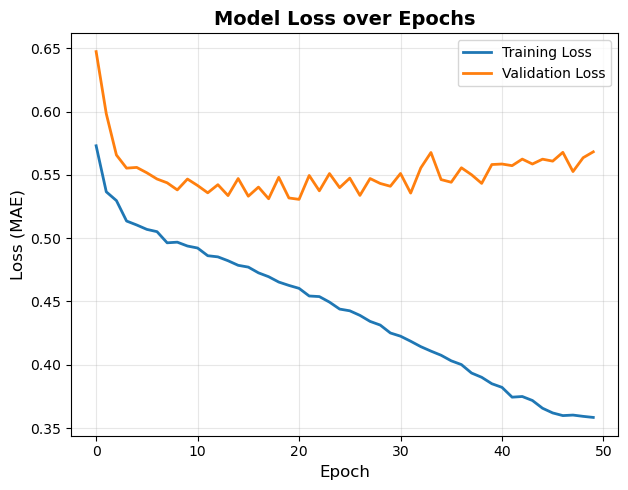


Final Training Loss: 0.358410
Final Validation Loss: 0.568183


In [22]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MAE)', fontsize=12)
plt.title('Model Loss over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Loss: {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.6f}")

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# First, check which variable is precipitation
print("=== Checking all variables ===")
for i in range(4):
    sample = data['train_target'].isel(variable=i, time=0).values
    nan_count = np.isnan(sample).sum()
    total = sample.size
    print(f"Variable {i}: NaN count = {nan_count}/{total} ({100*nan_count/total:.1f}%)")
    if nan_count == 0:
        print(f"  -> Valid data, range: [{sample.min():.4f}, {sample.max():.4f}]")

# Set precipitation variable index - CHANGE THIS based on output above
target_var_idx = 3  # Change if precipitation is at a different index

# Check if you have the original unnormalized data for precipitation
try:
    # Try to get stats from the original datasets
    original_target_var = ds_truth['tp']  # 'tp' for total precipitation, adjust if different
    
    # Calculate mean and std from original data
    target_mean = original_target_var.mean().values
    target_std = original_target_var.std().values
    
    print(f"\nDenormalization parameters for precipitation:")
    print(f"Mean: {target_mean}")
    print(f"Std: {target_std}")
    
except:
    print("Warning: Could not load original data for denormalization")
    print("Using normalized values. Please provide normalization parameters.")
    target_mean = 0
    target_std = 1

# Denormalize function
def denormalize(data, mean, std):
    """Convert normalized data back to original scale"""
    return data * std + mean

# Denormalize predictions and targets
predictions_denorm = denormalize(predictions, target_mean, target_std)
targets_denorm = denormalize(targets, target_mean, target_std)

# Get latitude and longitude coordinates
lats = data['val_input'].latitude.values
lons = data['val_input'].longitude.values

# Function to plot precipitation samples with SAME vmin/vmax for input, prediction, and target
def plot_precipitation_cartopy(predictions, targets, n_samples=3):
    n_val = len(predictions)
    random_indices = np.random.choice(n_val, size=n_samples, replace=False)
    
    lon_min, lon_max = lons.min(), lons.max()
    lat_min, lat_max = lats.min(), lats.max()
    
    for idx in random_indices:
        fig = plt.figure(figsize=(20, 5))
        
        # Get DENORMALIZED data
        input_sample_norm = data['val_input'].isel(time=idx).values[:, :, target_var_idx]
        input_sample = denormalize(input_sample_norm, target_mean, target_std)
        prediction_sample = predictions[idx, :, :, 0]
        target_sample = targets[idx, :, :, 0]
        bias = prediction_sample - target_sample
        
        # CRITICAL: Calculate GLOBAL vmin/vmax across INPUT, PREDICTION, and TARGET
        vmin = min(input_sample.min(), prediction_sample.min(), target_sample.min())
        vmax = max(input_sample.max(), prediction_sample.max(), target_sample.max())
        
        # For precipitation, ensure vmin is at least 0 (no negative precipitation)
        vmin = max(0, vmin)
        
        print(f"Sample {idx} - Precipitation range: [{vmin:.4f}, {vmax:.4f}] mm")
        
        # 1. Input - using SAME vmin/vmax
        ax1 = plt.subplot(1, 4, 1, projection=ccrs.PlateCarree())
        ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        im1 = ax1.pcolormesh(lons, lats, input_sample, 
                             transform=ccrs.PlateCarree(), 
                             cmap='YlGnBu', vmin=vmin, vmax=vmax, shading='auto')
        ax1.coastlines(resolution='10m', linewidth=0.8)
        ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
        ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        ax1.set_title(f'Input (Sample {idx})', fontweight='bold', fontsize=12)
        cbar1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
        cbar1.set_label('Total Precipitation (mm)', fontsize=10)
        
        # 2. Prediction - using SAME vmin/vmax
        ax2 = plt.subplot(1, 4, 2, projection=ccrs.PlateCarree())
        ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        im2 = ax2.pcolormesh(lons, lats, prediction_sample, 
                             transform=ccrs.PlateCarree(), 
                             cmap='YlGnBu', vmin=vmin, vmax=vmax, shading='auto')
        ax2.coastlines(resolution='10m', linewidth=0.8)
        ax2.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
        ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        ax2.set_title('Prediction', fontweight='bold', fontsize=12)
        cbar2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
        cbar2.set_label('Total Precipitation (mm)', fontsize=10)
        
        # 3. Target - using SAME vmin/vmax
        ax3 = plt.subplot(1, 4, 3, projection=ccrs.PlateCarree())
        ax3.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        im3 = ax3.pcolormesh(lons, lats, target_sample, 
                             transform=ccrs.PlateCarree(), 
                             cmap='YlGnBu', vmin=vmin, vmax=vmax, shading='auto')
        ax3.coastlines(resolution='10m', linewidth=0.8)
        ax3.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
        ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        ax3.set_title('Target (Truth)', fontweight='bold', fontsize=12)
        cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.8)
        cbar3.set_label('Total Precipitation (mm)', fontsize=10)
        
        # 4. Bias - using symmetric scale
        ax4 = plt.subplot(1, 4, 4, projection=ccrs.PlateCarree())
        ax4.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        bias_max = max(abs(bias.min()), abs(bias.max()))
        im4 = ax4.pcolormesh(lons, lats, bias, 
                             transform=ccrs.PlateCarree(), 
                             cmap='seismic', vmin=-bias_max, vmax=bias_max, shading='auto')
        ax4.coastlines(resolution='10m', linewidth=0.8)
        ax4.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
        ax4.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        ax4.set_title('Bias (Pred - Truth)', fontweight='bold', fontsize=12)
        cbar4 = plt.colorbar(im4, ax=ax4, orientation='horizontal', pad=0.05, shrink=0.8)
        cbar4.set_label('Precipitation Difference (mm)', fontsize=10)
        
        # Add statistics
        mae = np.mean(np.abs(bias))
        rmse = np.sqrt(np.mean(bias**2))
        ax4.text(0.02, 0.98, f'MAE: {mae:.2f} mm\nRMSE: {rmse:.2f} mm', 
                transform=ax4.transAxes, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                fontsize=10, fontweight='bold')
        
        plt.suptitle(f'Sample {idx} - Total Precipitation Performance (Actual Values)', 
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

# Plot precipitation samples
plot_precipitation_cartopy(predictions_denorm, targets_denorm, n_samples=3)


# Overall precipitation statistics
def plot_overall_precipitation_stats(predictions, targets):
    all_bias = predictions[:, :, :, 0] - targets[:, :, :, 0]
    
    lon_min, lon_max = lons.min(), lons.max()
    lat_min, lat_max = lats.min(), lats.max()
    
    fig = plt.figure(figsize=(18, 5))
    
    # 1. Mean Bias
    ax1 = plt.subplot(1, 3, 1, projection=ccrs.PlateCarree())
    ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    mean_bias = np.mean(all_bias, axis=0)
    bias_max = max(abs(mean_bias.min()), abs(mean_bias.max()))
    im1 = ax1.pcolormesh(lons, lats, mean_bias, 
                         transform=ccrs.PlateCarree(), 
                         cmap='seismic', vmin=-bias_max, vmax=bias_max, shading='auto')
    ax1.coastlines(resolution='10m', linewidth=0.8)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    ax1.add_feature(cfeature.LAND, alpha=0.1)
    ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    ax1.set_title('Mean Bias (All Samples)', fontweight='bold', fontsize=12)
    cbar1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar1.set_label('Precipitation (mm)', fontsize=10)
    
    # 2. MAE
    ax2 = plt.subplot(1, 3, 2, projection=ccrs.PlateCarree())
    ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    mae_spatial = np.mean(np.abs(all_bias), axis=0)
    im2 = ax2.pcolormesh(lons, lats, mae_spatial, 
                         transform=ccrs.PlateCarree(), 
                         cmap='YlOrRd', shading='auto')
    ax2.coastlines(resolution='10m', linewidth=0.8)
    ax2.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    ax2.add_feature(cfeature.LAND, alpha=0.1)
    ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    ax2.set_title('Mean Absolute Error (Spatial)', fontweight='bold', fontsize=12)
    cbar2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar2.set_label('MAE (mm)', fontsize=10)
    
    # 3. RMSE
    ax3 = plt.subplot(1, 3, 3, projection=ccrs.PlateCarree())
    ax3.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    rmse_spatial = np.sqrt(np.mean(all_bias**2, axis=0))
    im3 = ax3.pcolormesh(lons, lats, rmse_spatial, 
                         transform=ccrs.PlateCarree(), 
                         cmap='YlOrRd', shading='auto')
    ax3.coastlines(resolution='10m', linewidth=0.8)
    ax3.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    ax3.add_feature(cfeature.LAND, alpha=0.1)
    ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    ax3.set_title('Root Mean Square Error (Spatial)', fontweight='bold', fontsize=12)
    cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar3.set_label('RMSE (mm)', fontsize=10)
    
    plt.suptitle('Overall Precipitation Performance - Indonesia Region', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"\nOverall Precipitation Metrics (Actual Values):")
    print(f"Mean Absolute Error: {np.mean(np.abs(all_bias)):.2f} mm")
    print(f"Root Mean Square Error: {np.sqrt(np.mean(all_bias**2)):.2f} mm")
    print(f"Mean Bias: {np.mean(all_bias):.2f} mm")
    print(f"Correlation: {np.corrcoef(predictions.flatten(), targets.flatten())[0,1]:.4f}")

plot_overall_precipitation_stats(predictions_denorm, targets_denorm)

=== Checking all variables ===
Variable 0: NaN count = 0/35200 (0.0%)
  -> Valid data, range: [-4.0054, 2.9325]
Variable 1: NaN count = 0/35200 (0.0%)
  -> Valid data, range: [-3.6066, 3.0014]
Variable 2: NaN count = 0/35200 (0.0%)
  -> Valid data, range: [-3.7417, 2.8288]
Variable 3: NaN count = 0/35200 (0.0%)
  -> Valid data, range: [-0.5399, 15.7983]
Using normalized values. Please provide normalization parameters.


NameError: name 'predictions' is not defined

In [5]:
data.keys()

NameError: name 'data' is not defined

In [36]:
# 1. Set the target variable index (3 = Precipitation)
target_var_idx = 3 

# 2. Define architecture parameters
ARCH_PARAMS = dict(
    n_filters=8,
    n_blocks=8,
    normalization=None,
    dropout_rate=0.0,
    dropout_variant='spatial',
    attention=False,
    activation='relu',
    localcon_layer=False
)

# 3. Initialize Trainer
trainer = dds.SupervisedTrainer(
    backbone='resnet',
    upsampling='pin', 
    
    # Use SLICE here to keep the 4th dimension (variable)
    data_train=data['train_target'].isel(variable=slice(target_var_idx, target_var_idx + 1)), 
    data_val=data['val_target'].isel(variable=slice(target_var_idx, target_var_idx + 1)),
    data_test=data['test_target'].isel(variable=slice(target_var_idx, target_var_idx + 1)),
    
    # Use SLICE here as well
    data_train_lr=data['train_input'].isel(variable=slice(target_var_idx, target_var_idx + 1)),
    data_val_lr=data['val_input'].isel(variable=slice(target_var_idx, target_var_idx + 1)),
    data_test_lr=data['test_input'].isel(variable=slice(target_var_idx, target_var_idx + 1)),
    
    # Ensure each predictor in the list is also 4D
    predictors_train=[data['train_input'].isel(variable=slice(i, i + 1)) for i in [0, 1, 2]],
    predictors_val=[data['val_input'].isel(variable=slice(i, i + 1)) for i in [0, 1, 2]],
    predictors_test=[data['test_input'].isel(variable=slice(i, i + 1)) for i in [0, 1, 2]],
    
    scale=1,  
    interpolation='inter_area',
    batch_size=60, 
    loss='mae',
    epochs=100, 
    learning_rate=(1e-3, 1e-4), 
    device='GPU', 
    **ARCH_PARAMS
)

trainer.run()

List of devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of devices: 1
Global batch size: 60
--------------------------------------------------------------------------------
Starting time: 2026-02-12 23:30:06
--------------------------------------------------------------------------------
Model: "resnet_pin"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                Output Shape                                 Param #        Connected to                                 
 input_8 (InputLayer)                        [(None, None, None, 4)]                      0              []                                           
                                                                                                                                                      
 conv2d_180 (Conv2D)                         (None, 